In [42]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image

In [ ]:
SEED = 7

## Ucitavanje skupa podataka

1. Napraviti nalog na Kaggle ako vec nemas
2. Gore desno na user-a se klikne -> Your API tokens
3. Klikni "Generate New Token"
4. Kada se generise token vidimo njegov hash, npr KGAT_365d6da2deb12abcf0d0139a7626ef40
5. Zatim taj token upisujes lokalno u kaggle.json (samo kod sebe, ne u repo):
   1. mkdir -p ~/.kaggle
   2. echo '{"username":"TVOJ_USERNAME","key":"TVOJ_TOKEN"}' > ~/.kaggle/kaggle.json
      (na mesto TVOJ_USERNAME pises svoj Kaggle username, na mesto TVOJ_TOKEN svoj token)
   4. chmod 600 ~/.kaggle/kaggle.json
   5. kaggle datasets download -d adityajn105/flickr8k
   6. unzip flickr8k.zip -d flickr8k

In [23]:
DATA_DIR = "./flickr8k"
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
CAPTIONS_FILE = os.path.join(DATA_DIR, "captions.txt")

In [24]:
captions_df = pd.read_csv(CAPTIONS_FILE)

In [25]:
captions_df.shape

(40455, 2)

In [36]:
captions_df.head(10)

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


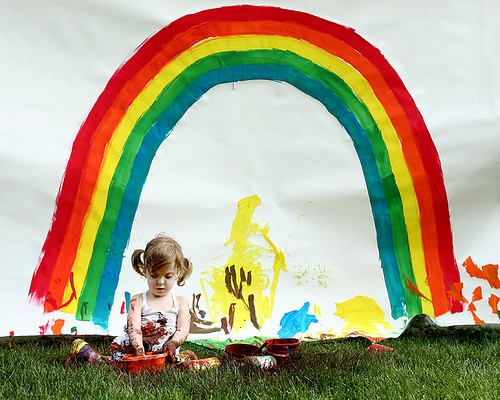

In [34]:
sample = captions_df.iloc[10]
image_path = os.path.join(IMAGES_DIR, sample["image"])
image = Image.open(image_path)
image

In [61]:
sample["caption"]


'A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .'

TODO opise tokenizirati

In [50]:
unique_images = captions_df["image"].unique()
train_images, test_val_images = train_test_split(unique_images, test_size=0.2, random_state=42)
val_images, test_images = train_test_split(test_val_images, test_size=0.5, random_state=42)

train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df = captions_df[captions_df["image"].isin(test_images)].reset_index(drop=True)


In [51]:
train_df.shape

(32360, 2)

In [53]:
val_df.shape

(4045, 2)

In [54]:
test_df.shape

(4050, 2)

# NE DIRATI TEST_DF DO KRAJA!!

In [39]:
from collections import Counter


In [56]:
sizes = []
for filename in train_images:
    path = os.path.join(IMAGES_DIR, filename)
    with Image.open(path) as img:
        sizes.append(img.size)

size_counts = Counter(sizes)

print(f"Broj razlicitih dimenzija: {len(size_counts)}")

Broj razlicitih dimenzija: 552


dimenzije slika nisu iste ali ResNet18 arhitektura to vec obradjuje tako sto ima nn.AdaptiveAvgPool2d((1, 1)) pre FC sloja na kraju

In [59]:
os.makedirs("data_setup", exist_ok=True)

train_df.to_csv("data_setup/train.csv", index=False)
val_df.to_csv("data_setup/val.csv", index=False)
test_df.to_csv("data_setup/test.csv", index=False)